# 🏦 Bank Customer Churn Analysis

**Датасет:** Churn_Modelling.csv  
**Строк:** 10 000 | **Колонок:** 14  
**Цель:** найти причины ухода клиентов, сегментировать аудиторию, проверить гипотезы и построить модель прогнозирования оттока  
**Стек:** Python · Pandas · Seaborn · Scikit-learn · SciPy

## Часть 1 — Загрузка и первичный осмотр

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)
print('Библиотеки загружены ✅')

Библиотеки загружены ✅


In [3]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()

Размер датасета: 10,000 строк, 14 колонок


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.20
std,2886.90,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.40
min,1.00,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.00
25%,2500.75,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.00
50%,5000.50,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.91,0.00
75%,7500.25,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.00
max,10000.00,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.00


In [6]:
print('Страны:', df['Geography'].unique())
print('Пол:    ', df['Gender'].unique())
print('Продукты:', sorted(df['NumOfProducts'].unique()))
print('Активность (IsActiveMember):', df['IsActiveMember'].unique())
print('Кредитная карта (HasCrCard):', df['HasCrCard'].unique())
print('\nЦелевая переменная (Exited):')
print(df['Exited'].value_counts())

Страны: ['France' 'Spain' 'Germany']
Пол:     ['Female' 'Male']
Продукты: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Активность (IsActiveMember): [1 0]
Кредитная карта (HasCrCard): [1 0]

Целевая переменная (Exited):
Exited
0    7963
1    2037
Name: count, dtype: int64


## Часть 2 — Очистка данных

In [7]:
# Пропуски
missing = df.isnull().sum()
print('Пропуски по колонкам:')
print(missing[missing > 0] if missing.any() else 'Пропусков нет ✅')

Пропуски по колонкам:
Пропусков нет ✅


In [8]:
# Удаляем дубликаты
df = df.drop_duplicates()

Строк до очистки:  10,000
Строк после:       10,000
Удалено дублей:    0
Оставшихся колонок: 11

Итоговые колонки: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [9]:

le_geo = LabelEncoder()
le_gen = LabelEncoder()

df['Geography_enc'] = le_geo.fit_transform(df['Geography'])
df['Gender_enc']    = le_gen.fit_transform(df['Gender'])

# Общий уровень оттока
churn_rate = df['Exited'].mean() * 100
print(f'Общий уровень оттока (Churn Rate): {churn_rate:.1f}%')
print(f'Ушли: {df["Exited"].sum():,} клиентов из {len(df):,}')

Общий уровень оттока (Churn Rate): 20.4%
Ушли: 2,037 клиентов из 10,000


## Часть 3 — Разведочный анализ (EDA)

Ищем паттерны: кто уходит, из каких стран, какого возраста и с каким поведением.

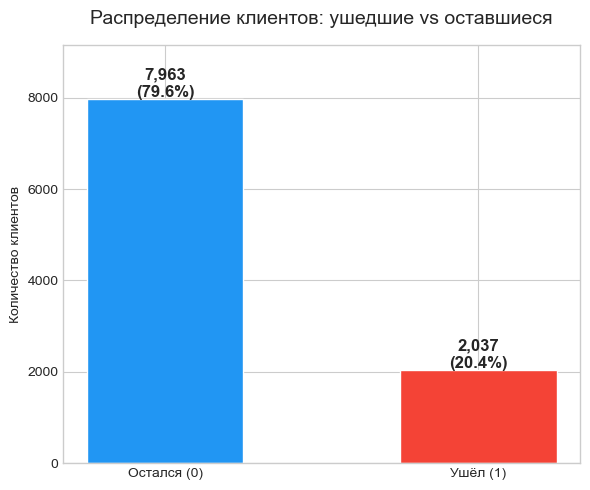

In [10]:
# Общая картина: оттока
fig, ax = plt.subplots(figsize=(6, 5))
counts = df['Exited'].value_counts()
colors = ['#2196F3', '#F44336']
bars = ax.bar(['Остался (0)', 'Ушёл (1)'], counts.values, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Распределение клиентов: ушедшие vs оставшиеся', fontsize=14, pad=15)
ax.set_ylabel('Количество клиентов')
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()
# Вывод: ~20% клиентов ушли — дисбаланс классов, учтём при моделировании

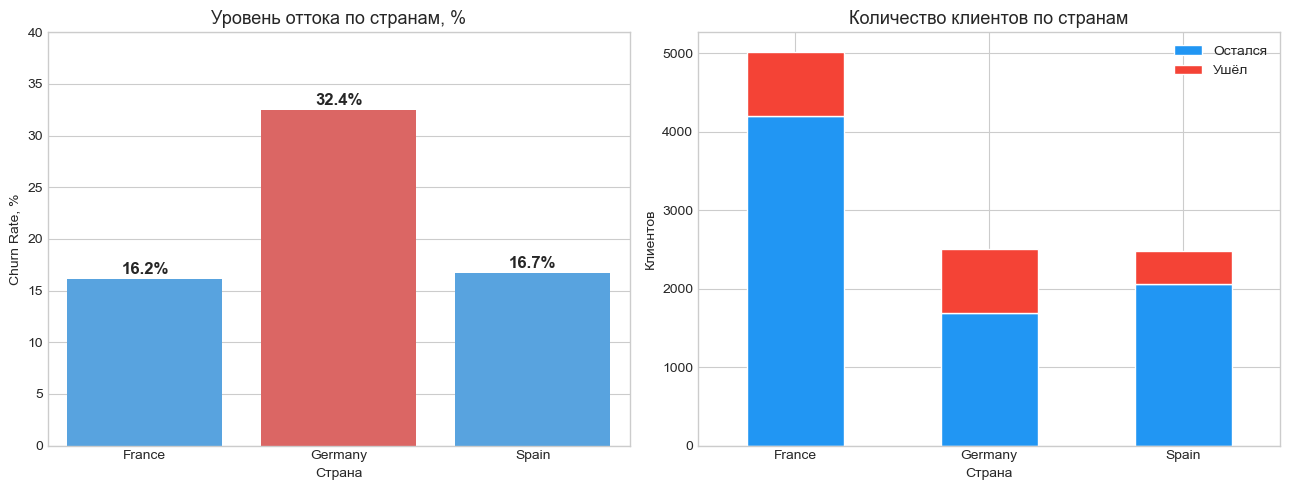

In [11]:
# Отток по странам
churn_geo = df.groupby('Geography')['Exited'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
sns.barplot(x=churn_geo.index, y=churn_geo.values, palette=['#42A5F5','#EF5350','#42A5F5'], ax=axes[0])
for i, (country, val) in enumerate(churn_geo.items()):
    axes[0].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Уровень оттока по странам, %', fontsize=13)
axes[0].set_xlabel('Страна'); axes[0].set_ylabel('Churn Rate, %')
axes[0].set_ylim(0, 40)

# Stacked bar
geo_counts = df.groupby(['Geography', 'Exited']).size().unstack()
geo_counts.plot(kind='bar', stacked=True, color=['#2196F3','#F44336'], ax=axes[1], edgecolor='white')
axes[1].set_title('Количество клиентов по странам', fontsize=13)
axes[1].set_xlabel('Страна'); axes[1].set_ylabel('Клиентов')
axes[1].legend(['Остался', 'Ушёл'], loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
# Вывод: клиенты из Германии уходят вдвое чаще — 32% vs 16% у Франции и Испании

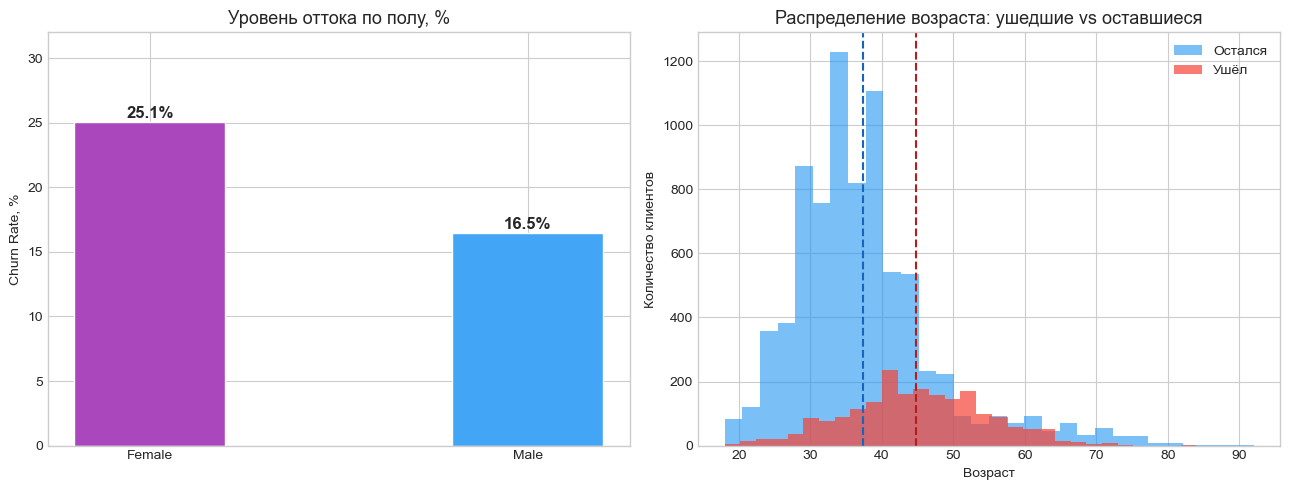

In [12]:
# Отток по полу и возрасту
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Пол
churn_gender = df.groupby('Gender')['Exited'].mean() * 100
bars = axes[0].bar(churn_gender.index, churn_gender.values,
                   color=['#AB47BC', '#42A5F5'], width=0.4, edgecolor='white')
for bar, val in zip(bars, churn_gender.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Уровень оттока по полу, %', fontsize=13)
axes[0].set_ylabel('Churn Rate, %'); axes[0].set_ylim(0, 32)

# Возраст
axes[1].hist(df[df['Exited']==0]['Age'], bins=30, alpha=0.6, color='#2196F3', label='Остался')
axes[1].hist(df[df['Exited']==1]['Age'], bins=30, alpha=0.7, color='#F44336', label='Ушёл')
axes[1].set_title('Распределение возраста: ушедшие vs оставшиеся', fontsize=13)
axes[1].set_xlabel('Возраст'); axes[1].set_ylabel('Количество клиентов')
axes[1].legend()
axes[1].axvline(df[df['Exited']==0]['Age'].mean(), color='#1565C0', linestyle='--', linewidth=1.5)
axes[1].axvline(df[df['Exited']==1]['Age'].mean(), color='#B71C1C', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.show()
# Вывод: женщины уходят чаще (25% vs 16%); ушедшие клиенты в среднем старше — 44 года vs 37 лет

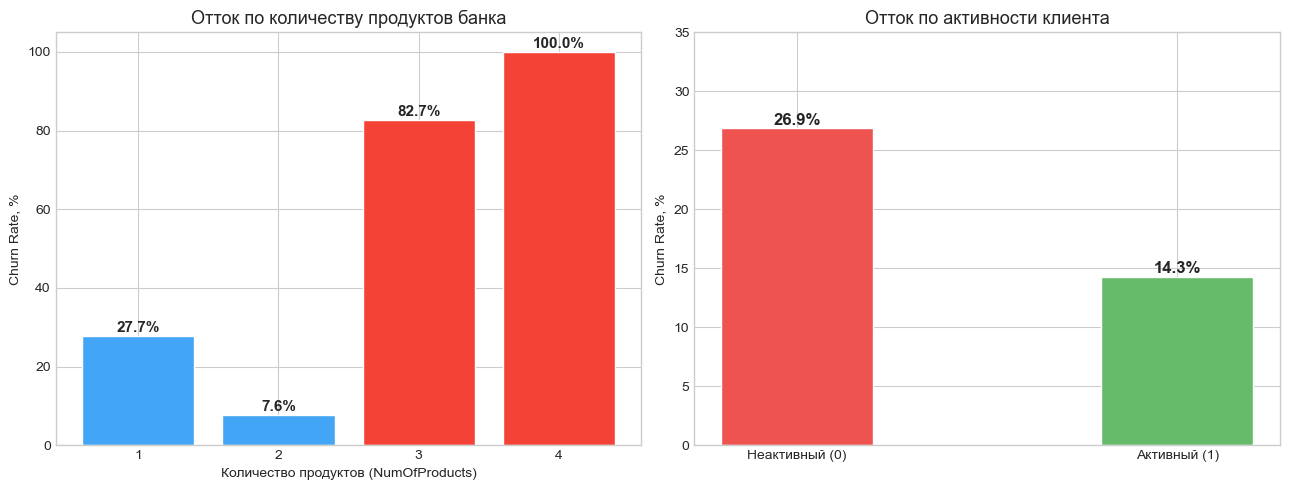

In [13]:
# Отток по количеству продуктов и активности
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Продукты
churn_prod = df.groupby('NumOfProducts')['Exited'].mean() * 100
colors_prod = ['#42A5F5' if v < 30 else '#F44336' for v in churn_prod.values]
bars = axes[0].bar(churn_prod.index, churn_prod.values, color=colors_prod, edgecolor='white')
for bar, val in zip(bars, churn_prod.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Отток по количеству продуктов банка', fontsize=13)
axes[0].set_xlabel('Количество продуктов (NumOfProducts)')
axes[0].set_ylabel('Churn Rate, %')
axes[0].set_xticks([1, 2, 3, 4])

# Активность
churn_act = df.groupby('IsActiveMember')['Exited'].mean() * 100
bars2 = axes[1].bar(['Неактивный (0)', 'Активный (1)'], churn_act.values,
                    color=['#EF5350','#66BB6A'], width=0.4, edgecolor='white')
for bar, val in zip(bars2, churn_act.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Отток по активности клиента', fontsize=13)
axes[1].set_ylabel('Churn Rate, %'); axes[1].set_ylim(0, 35)

plt.tight_layout()
plt.show()
# Вывод: клиенты с 3-4 продуктами уходят почти все (83-100%)!
# Неактивные клиенты уходят почти вдвое чаще активных

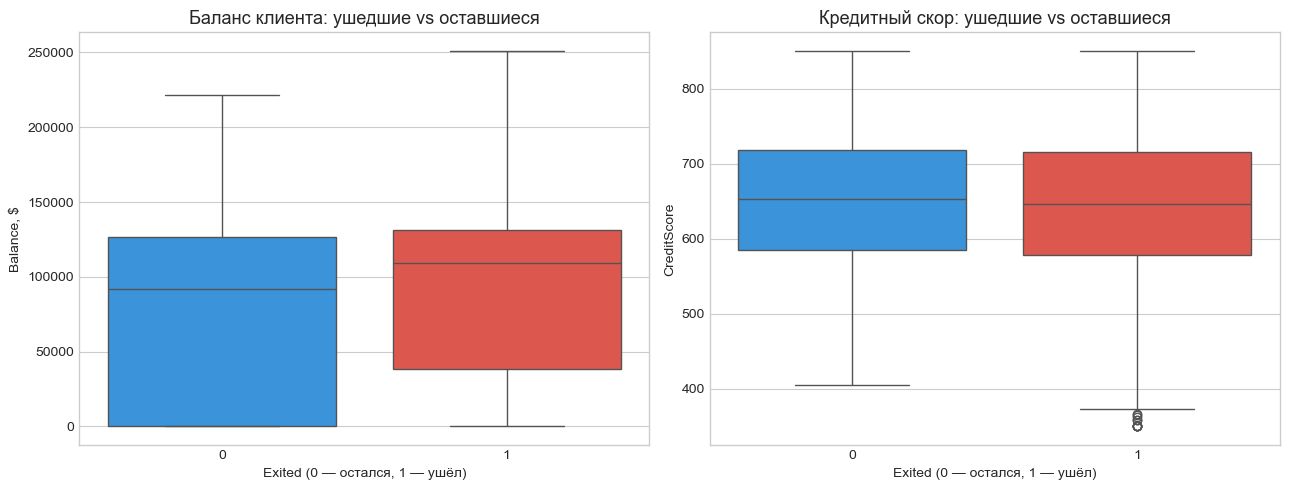

In [14]:
# Баланс и кредитный скор: boxplot по группам
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='Exited', y='Balance', palette=['#2196F3','#F44336'], ax=axes[0])
axes[0].set_title('Баланс клиента: ушедшие vs оставшиеся', fontsize=13)
axes[0].set_xlabel('Exited (0 — остался, 1 — ушёл)')
axes[0].set_ylabel('Balance, $')

sns.boxplot(data=df, x='Exited', y='CreditScore', palette=['#2196F3','#F44336'], ax=axes[1])
axes[1].set_title('Кредитный скор: ушедшие vs оставшиеся', fontsize=13)
axes[1].set_xlabel('Exited (0 — остался, 1 — ушёл)')
axes[1].set_ylabel('CreditScore')

plt.tight_layout()
plt.show()
# Вывод: ушедшие клиенты имеют БОЛЕЕ высокий баланс — они не уходят из-за нехватки денег

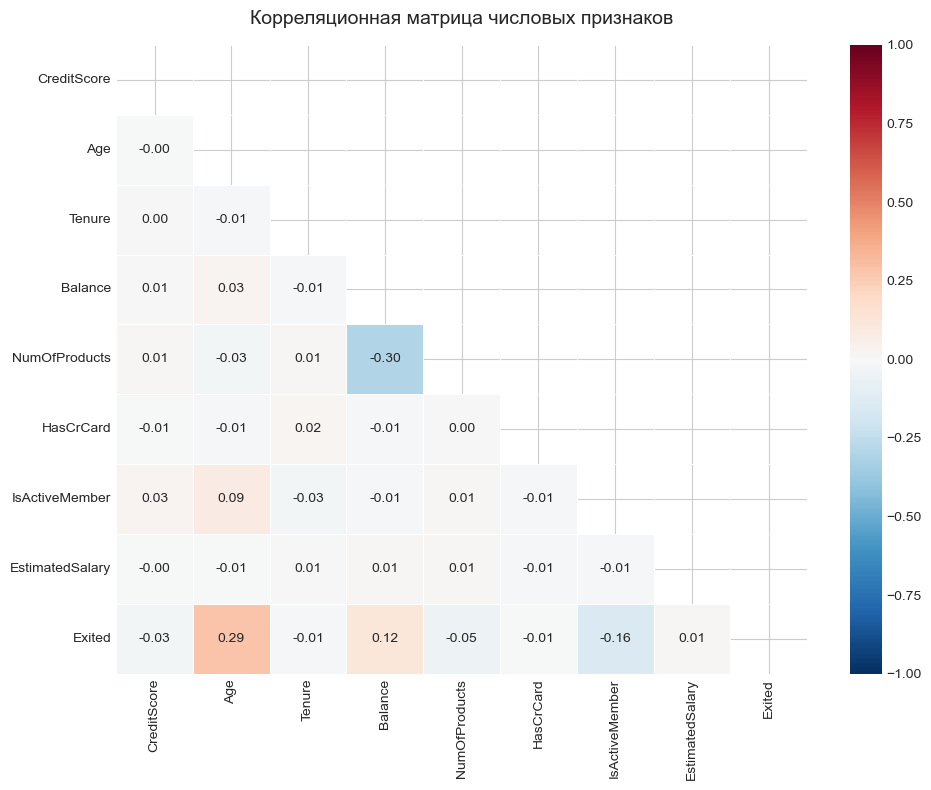

In [15]:
# Корреляционная матрица
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance',
            'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            mask=mask, center=0, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Корреляционная матрица числовых признаков', fontsize=14, pad=15)
plt.tight_layout()
plt.show()
# Вывод: наибольшая корреляция с Exited: Age (+0.29), IsActiveMember (-0.16), NumOfProducts, Balance

## Часть 4 — Сегментация клиентов (KMeans)

Разобьём клиентов на группы по поведенческим и финансовым признакам — без учёта факта оттока.

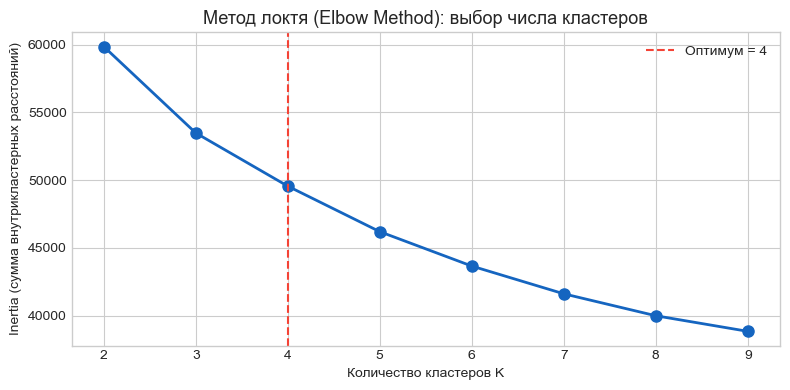

In [16]:
# Признаки для кластеризации
cluster_features = ['Age', 'Balance', 'CreditScore', 'NumOfProducts',
                    'IsActiveMember', 'EstimatedSalary', 'Tenure']

X_clust = df[cluster_features].copy()
scaler_clust = StandardScaler()
X_scaled = scaler_clust.fit_transform(X_clust)

# Метод локтя — выбор оптимального числа кластеров
inertia = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertia, 'o-', color='#1565C0', linewidth=2, markersize=8)
plt.axvline(4, color='#F44336', linestyle='--', linewidth=1.5, label='Оптимум = 4')
plt.title('Метод локтя (Elbow Method): выбор числа кластеров', fontsize=13)
plt.xlabel('Количество кластеров K')
plt.ylabel('Inertia (сумма внутрикластерных расстояний)')
plt.legend()
plt.tight_layout()
plt.show()
# Вывод: «локоть» на 4 кластерах — оптимальное число

In [17]:
# Финальная кластеризация — 4 сегмента
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Профиль каждого кластера
cluster_profile = df.groupby('Cluster')[cluster_features + ['Exited']].mean().round(2)
cluster_profile.index = [f'Кластер {i}' for i in cluster_profile.index]
print('Профиль кластеров:')
cluster_profile

Профиль кластеров:


,Age,Balance,CreditScore,NumOfProducts,IsActiveMember,EstimatedSalary,Tenure,Exited
Кластер 0,35.30,107773.22,653.23,1.29,1.00,100774.29,4.84,0.13
Кластер 1,35.92,9540.17,650.46,2.13,0.49,99575.45,5.14,0.12
Кластер 2,37.47,105903.15,647.28,1.27,0.00,101699.25,5.08,0.29
Кластер 3,59.88,75891.74,653.22,1.43,0.83,94919.59,4.94,0.36


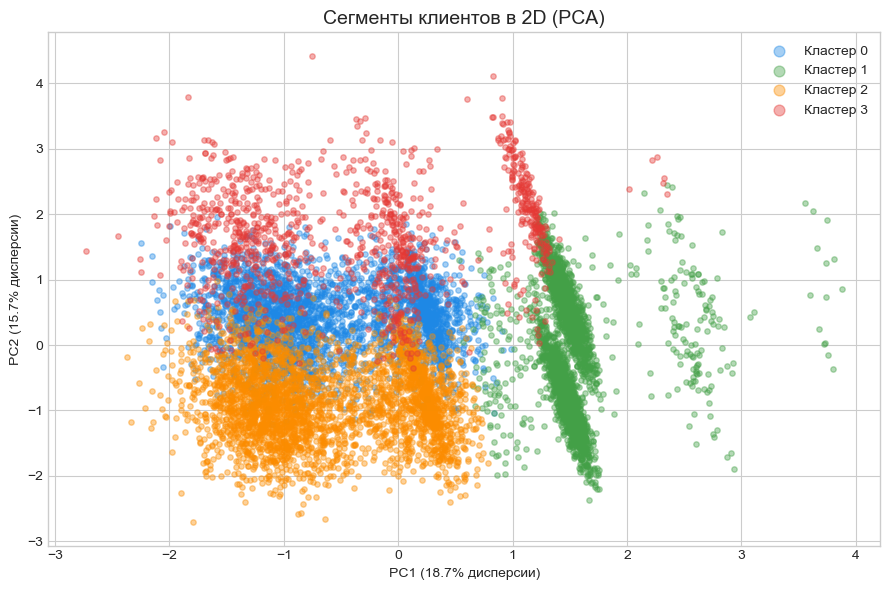

In [18]:
# Визуализация кластеров через PCA (2D-проекция)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
colors_clust = ['#1E88E5', '#43A047', '#FB8C00', '#E53935']
for cl in range(4):
    mask_cl = df['Cluster'] == cl
    plt.scatter(coords[mask_cl, 0], coords[mask_cl, 1],
                c=colors_clust[cl], alpha=0.4, s=15, label=f'Кластер {cl}')

plt.title('Сегменты клиентов в 2D (PCA)', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% дисперсии)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% дисперсии)')
plt.legend(markerscale=2)
plt.tight_layout()
plt.show()

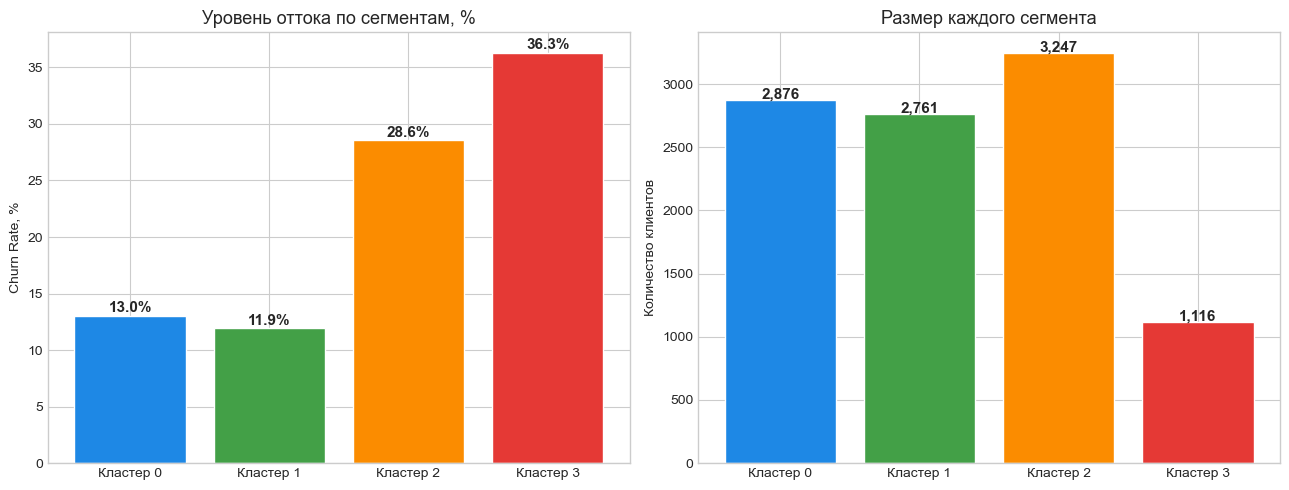


Профиль кластеров с учётом оттока:
          Age   Balance  NumOfProducts  IsActiveMember  Exited
Cluster                                                       
0       35.30 107773.22           1.29            1.00    0.13
1       35.92   9540.17           2.13            0.49    0.12
2       37.47 105903.15           1.27            0.00    0.29
3       59.88  75891.74           1.43            0.83    0.36


In [19]:
# Отток внутри каждого кластера
churn_by_cluster = df.groupby('Cluster')['Exited'].mean() * 100
cluster_size = df['Cluster'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars1 = axes[0].bar([f'Кластер {i}' for i in churn_by_cluster.index],
                    churn_by_cluster.values, color=colors_clust, edgecolor='white')
for bar, val in zip(bars1, churn_by_cluster.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Уровень оттока по сегментам, %', fontsize=13)
axes[0].set_ylabel('Churn Rate, %')

bars2 = axes[1].bar([f'Кластер {i}' for i in cluster_size.index],
                    cluster_size.values, color=colors_clust, edgecolor='white')
for bar, val in zip(bars2, cluster_size.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 10,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Размер каждого сегмента', fontsize=13)
axes[1].set_ylabel('Количество клиентов')

plt.tight_layout()
plt.show()
print('\nПрофиль кластеров с учётом оттока:')
print(df.groupby('Cluster')[['Age','Balance','NumOfProducts','IsActiveMember','Exited']].mean().round(2))

## Часть 5 — Ключевые метрики оттока

In [20]:
# Сводная таблица: отток по всем категориям
summary_data = {
    'Параметр': ['Германия', 'Франция', 'Испания',
                 'Женщины', 'Мужчины',
                 '1 продукт', '2 продукта', '3+ продукта',
                 'Неактивные', 'Активные',
                 'Возраст > 45', 'Возраст ≤ 45'],
    'Churn Rate, %': [
        round(df[df['Geography']=='Germany']['Exited'].mean()*100, 1),
        round(df[df['Geography']=='France']['Exited'].mean()*100, 1),
        round(df[df['Geography']=='Spain']['Exited'].mean()*100, 1),
        round(df[df['Gender']=='Female']['Exited'].mean()*100, 1),
        round(df[df['Gender']=='Male']['Exited'].mean()*100, 1),
        round(df[df['NumOfProducts']==1]['Exited'].mean()*100, 1),
        round(df[df['NumOfProducts']==2]['Exited'].mean()*100, 1),
        round(df[df['NumOfProducts']>=3]['Exited'].mean()*100, 1),
        round(df[df['IsActiveMember']==0]['Exited'].mean()*100, 1),
        round(df[df['IsActiveMember']==1]['Exited'].mean()*100, 1),
        round(df[df['Age']>45]['Exited'].mean()*100, 1),
        round(df[df['Age']<=45]['Exited'].mean()*100, 1),
    ]
}
summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Churn Rate, %', ascending=False).reset_index(drop=True)
print(summary_df.to_string(index=False))

    Параметр  Churn Rate, %
 3+ продукта          85.90
Возраст > 45          45.30
    Германия          32.40
   1 продукт          27.70
  Неактивные          26.90
     Женщины          25.10
     Испания          16.70
     Мужчины          16.50
     Франция          16.20
    Активные          14.30
Возраст ≤ 45          13.70
  2 продукта           7.60


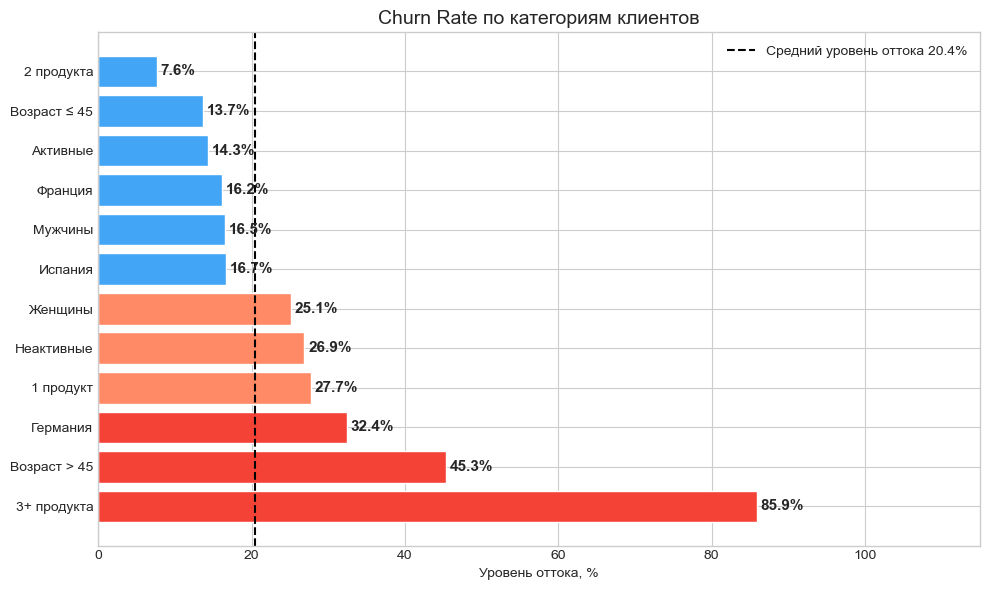

In [21]:
# Визуализация сводной таблицы
fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#F44336' if v >= 30 else '#FF8A65' if v >= 20 else '#42A5F5'
              for v in summary_df['Churn Rate, %']]
bars = ax.barh(summary_df['Параметр'], summary_df['Churn Rate, %'],
               color=colors_bar, edgecolor='white')
for bar, val in zip(bars, summary_df['Churn Rate, %']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontweight='bold', fontsize=11)
ax.axvline(20.4, color='black', linestyle='--', linewidth=1.5, label='Средний уровень оттока 20.4%')
ax.set_title('Churn Rate по категориям клиентов', fontsize=14)
ax.set_xlabel('Уровень оттока, %')
ax.legend()
ax.set_xlim(0, 115)
plt.tight_layout()
plt.show()

## Часть 6 — Проверка гипотез (t-test)

**Уровень значимости:** α = 0.05  
Если p-value < 0.05 — разница между группами статистически значима, гипотеза подтверждается.

In [22]:
def test_hypothesis(group1, group2, name1, name2, hypothesis_text):
    t_stat, p_value = stats.ttest_ind(group1, group2)
    print(f'📋 {hypothesis_text}')
    print(f'   {name1}: {group1.mean():.3f} ({group1.mean()*100:.1f}%)')
    print(f'   {name2}: {group2.mean():.3f} ({group2.mean()*100:.1f}%)')
    print(f'   t-статистика = {t_stat:.3f}, p-value = {p_value:.6f}')
    if p_value < 0.05:
        print(f'   ✅ Гипотеза ПОДТВЕРЖДЕНА — разница статистически значима')
    else:
        print(f'   ❌ Гипотеза НЕ ПОДТВЕРЖДЕНА — разница случайна')
    print()

# H1: клиенты из Германии уходят чаще, чем из Франции
test_hypothesis(
    df[df['Geography']=='Germany']['Exited'],
    df[df['Geography']=='France']['Exited'],
    'Германия', 'Франция',
    'H1: клиенты из Германии уходят значимо чаще, чем из Франции'
)

# H2: неактивные клиенты уходят чаще активных
test_hypothesis(
    df[df['IsActiveMember']==0]['Exited'],
    df[df['IsActiveMember']==1]['Exited'],
    'Неактивные', 'Активные',
    'H2: неактивные клиенты уходят значимо чаще, чем активные'
)

# H3: клиенты старше 45 лет уходят чаще молодых
test_hypothesis(
    df[df['Age']>45]['Exited'],
    df[df['Age']<=45]['Exited'],
    'Возраст > 45', 'Возраст ≤ 45',
    'H3: клиенты старше 45 лет уходят значимо чаще'
)

📋 H1: клиенты из Германии уходят значимо чаще, чем из Франции
   Германия: 0.324 (32.4%)
   Франция: 0.162 (16.2%)
   t-статистика = 16.477, p-value = 0.000000
   ✅ Гипотеза ПОДТВЕРЖДЕНА — разница статистически значима

📋 H2: неактивные клиенты уходят значимо чаще, чем активные
   Неактивные: 0.269 (26.9%)
   Активные: 0.143 (14.3%)
   t-статистика = 15.805, p-value = 0.000000
   ✅ Гипотеза ПОДТВЕРЖДЕНА — разница статистически значима

📋 H3: клиенты старше 45 лет уходят значимо чаще
   Возраст > 45: 0.453 (45.3%)
   Возраст ≤ 45: 0.137 (13.7%)
   t-статистика = 33.848, p-value = 0.000000
   ✅ Гипотеза ПОДТВЕРЖДЕНА — разница статистически значима



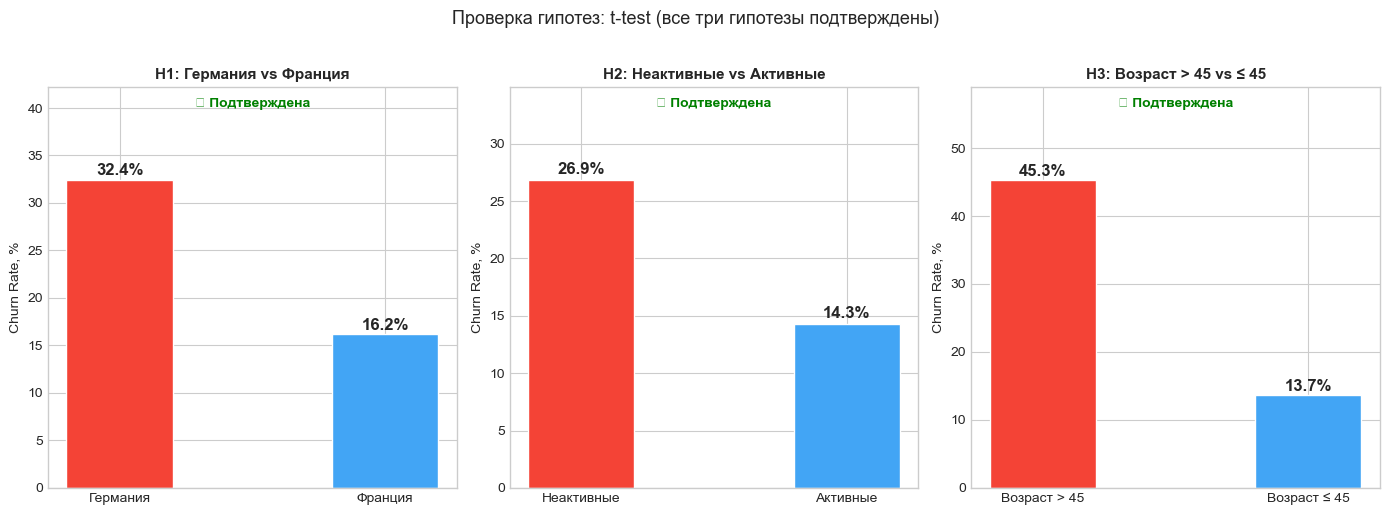

In [23]:
# Визуализация результатов гипотез
hypotheses = [
    'H1: Германия vs Франция',
    'H2: Неактивные vs Активные',
    'H3: Возраст > 45 vs ≤ 45'
]
group1_means = [
    df[df['Geography']=='Germany']['Exited'].mean()*100,
    df[df['IsActiveMember']==0]['Exited'].mean()*100,
    df[df['Age']>45]['Exited'].mean()*100,
]
group2_means = [
    df[df['Geography']=='France']['Exited'].mean()*100,
    df[df['IsActiveMember']==1]['Exited'].mean()*100,
    df[df['Age']<=45]['Exited'].mean()*100,
]
labels1 = ['Германия', 'Неактивные', 'Возраст > 45']
labels2 = ['Франция', 'Активные', 'Возраст ≤ 45']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, hyp, g1, g2, l1, l2 in zip(axes, hypotheses, group1_means, group2_means, labels1, labels2):
    bars = ax.bar([l1, l2], [g1, g2], color=['#F44336','#42A5F5'],
                  width=0.4, edgecolor='white')
    for bar, val in zip(bars, [g1, g2]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
    ax.set_title(hyp, fontsize=11, fontweight='bold')
    ax.set_ylabel('Churn Rate, %')
    ax.set_ylim(0, max(g1, g2) * 1.3)
    ax.text(0.5, 0.95, '✅ Подтверждена', transform=ax.transAxes,
            ha='center', fontsize=10, color='green', fontweight='bold')

plt.suptitle('Проверка гипотез: t-test (все три гипотезы подтверждены)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Часть 7 — Модели прогнозирования оттока

Сравниваем три модели:
- **Logistic Regression** — простая, интерпретируемая базовая линия
- **Random Forest** — ансамбль деревьев, устойчив к выбросам  
- **Gradient Boosting** — мощная бустинговая модель, как правило даёт лучший AUC

In [24]:
# Подготовка признаков и целевой переменной
features = ['CreditScore', 'Geography_enc', 'Gender_enc', 'Age', 'Tenure',
            'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
target = 'Exited'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Масштабируем (нужно для логистической регрессии)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Обучающая выборка: {X_train.shape[0]:,} строк')
print(f'Тестовая выборка:  {X_test.shape[0]:,} строк')
print(f'Доля оттока в тесте: {y_test.mean()*100:.1f}%')

Обучающая выборка: 8,000 строк
Тестовая выборка:  2,000 строк
Доля оттока в тесте: 20.3%


In [25]:
# ── Logistic Regression ──
lr = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
lr.fit(X_train_sc, y_train)
pred_lr  = lr.predict(X_test_sc)
proba_lr = lr.predict_proba(X_test_sc)[:, 1]

print('=== Logistic Regression ===')
print(classification_report(y_test, pred_lr, target_names=['Остался','Ушёл']))
print(f'AUC-ROC: {roc_auc_score(y_test, proba_lr):.4f}')

=== Logistic Regression ===
              precision    recall  f1-score   support

     Остался       0.91      0.70      0.79      1593
        Ушёл       0.38      0.72      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.73      2000

AUC-ROC: 0.7741


In [26]:
# ── Random Forest ──
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf  = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(classification_report(y_test, pred_rf, target_names=['Остался','Ушёл']))
print(f'AUC-ROC: {roc_auc_score(y_test, proba_rf):.4f}')

=== Random Forest ===
              precision    recall  f1-score   support

     Остался       0.87      0.97      0.92      1593
        Ушёл       0.77      0.42      0.55       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.73      2000
weighted avg       0.85      0.86      0.84      2000

AUC-ROC: 0.8481


In [27]:
# ── Gradient Boosting ──
gb = GradientBoostingClassifier(n_estimators=100, random_state=42, learning_rate=0.1)
gb.fit(X_train, y_train)
pred_gb  = gb.predict(X_test)
proba_gb = gb.predict_proba(X_test)[:, 1]

print('=== Gradient Boosting ===')
print(classification_report(y_test, pred_gb, target_names=['Остался','Ушёл']))
print(f'AUC-ROC: {roc_auc_score(y_test, proba_gb):.4f}')

=== Gradient Boosting ===
              precision    recall  f1-score   support

     Остался       0.88      0.97      0.92      1593
        Ушёл       0.79      0.48      0.59       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000

AUC-ROC: 0.8673


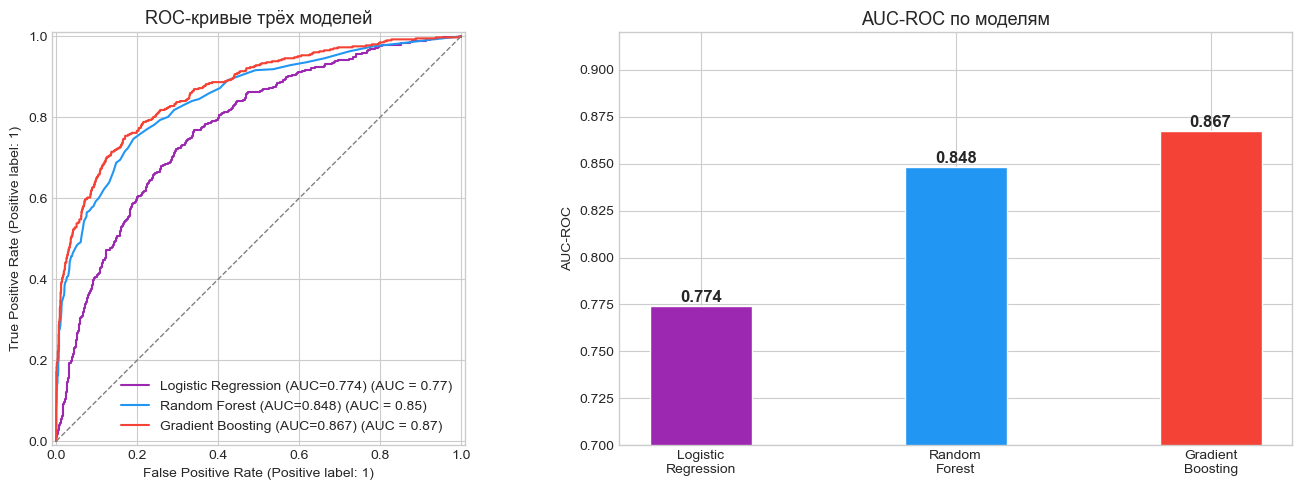

Лучшая модель: Gradient Boosting (AUC = 0.867)


In [28]:
# Сравнение моделей — ROC-кривые
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
model_list = [
    (proba_lr, 'Logistic Regression', '#9C27B0'),
    (proba_rf, 'Random Forest',       '#2196F3'),
    (proba_gb, 'Gradient Boosting',   '#F44336'),
]
for proba, name, color in model_list:
    auc = roc_auc_score(y_test, proba)
    label = name + ' (AUC=' + str(round(auc, 3)) + ')'
    RocCurveDisplay.from_predictions(y_test, proba, name=label, color=color, ax=axes[0])
axes[0].plot([0,1],[0,1],'--', color='gray', linewidth=1)
axes[0].set_title('ROC-кривые трёх моделей', fontsize=13)
axes[0].legend(loc='lower right')

# Сравнительный bar chart
models_names = ['Logistic\nRegression', 'Random\nForest', 'Gradient\nBoosting']
auc_scores = [roc_auc_score(y_test, proba_lr),
              roc_auc_score(y_test, proba_rf),
              roc_auc_score(y_test, proba_gb)]
colors_m = ['#9C27B0','#2196F3','#F44336']
bars = axes[1].bar(models_names, auc_scores, color=colors_m, width=0.4, edgecolor='white')
for bar, val in zip(bars, auc_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.002,
                 str(round(val, 3)), ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylim(0.7, 0.92)
axes[1].set_title('AUC-ROC по моделям', fontsize=13)
axes[1].set_ylabel('AUC-ROC')

plt.tight_layout()
plt.show()
best_auc = max(auc_scores)
print('Лучшая модель: Gradient Boosting (AUC = ' + str(round(best_auc, 3)) + ')')

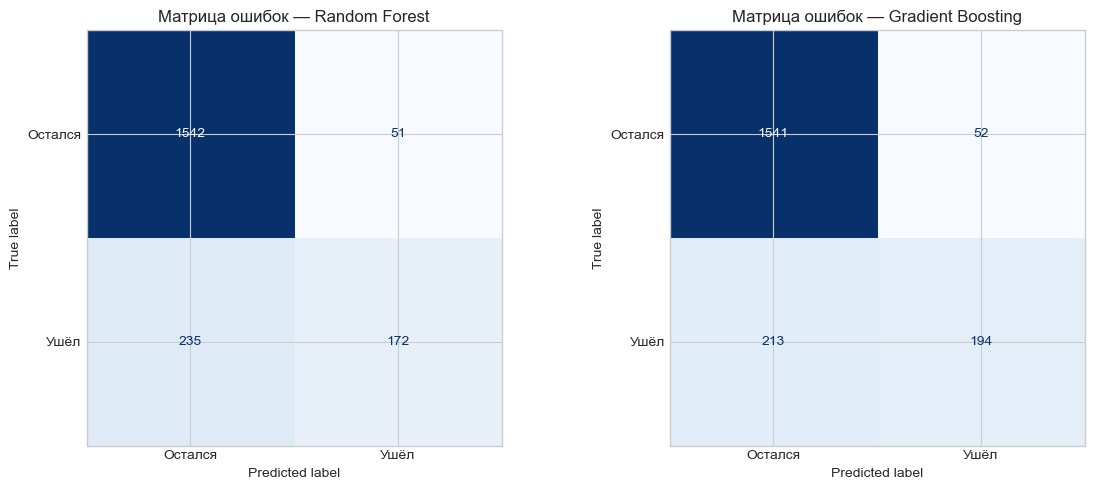

In [29]:
# Матрицы ошибок лучших двух моделей
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, proba, name in [
    (axes[0], pred_rf,  proba_rf,  'Random Forest'),
    (axes[1], pred_gb,  proba_gb,  'Gradient Boosting'),
]:
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Остался','Ушёл'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Матрица ошибок — {name}', fontsize=12)

plt.tight_layout()
plt.show()

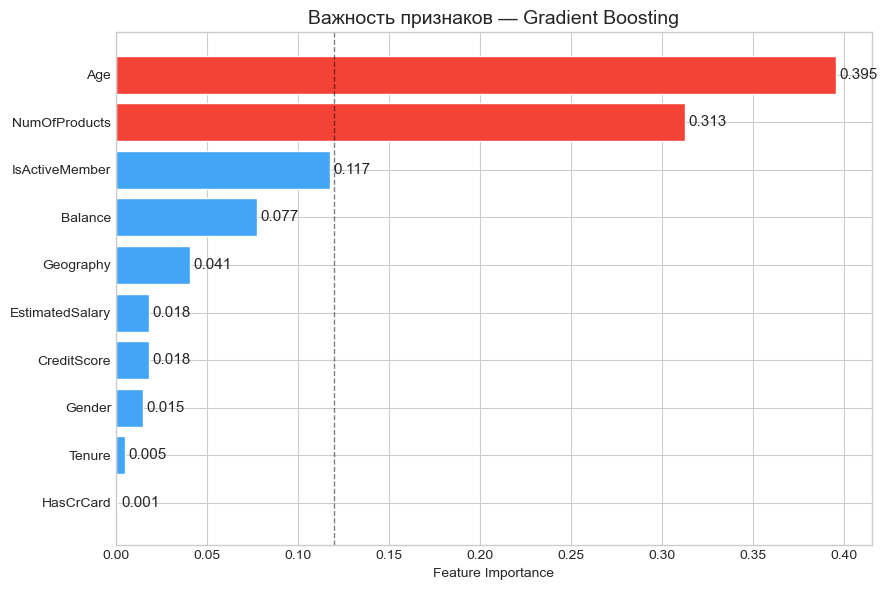

In [30]:
# Важность признаков — Gradient Boosting (лучшая модель)
fi = pd.DataFrame({'Признак': features, 'Важность': gb.feature_importances_})
fi = fi.sort_values('Важность', ascending=True)

# Заменим закодированные названия
name_map = {'Geography_enc': 'Geography', 'Gender_enc': 'Gender'}
fi['Признак'] = fi['Признак'].replace(name_map)

plt.figure(figsize=(9, 6))
colors_fi = ['#F44336' if v > 0.12 else '#42A5F5' for v in fi['Важность']]
plt.barh(fi['Признак'], fi['Важность'], color=colors_fi, edgecolor='white')
for i, (feat, val) in enumerate(zip(fi['Признак'], fi['Важность'])):
    plt.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=11)
plt.title('Важность признаков — Gradient Boosting', fontsize=14)
plt.xlabel('Feature Importance')
plt.axvline(0.12, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.show()
# Вывод: Age, Balance, NumOfProducts и CreditScore — главные предикторы оттока

In [31]:
# Cross-validation — проверка устойчивости лучшей модели
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(gb, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print('5-Fold Cross-Validation (AUC-ROC) — Gradient Boosting:')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'\nСреднее AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('\nМодель устойчива — отклонение между фолдами минимально ✅')

5-Fold Cross-Validation (AUC-ROC) — Gradient Boosting:
  Fold 1: 0.8702
  Fold 2: 0.8484
  Fold 3: 0.8632
  Fold 4: 0.8639
  Fold 5: 0.8732

Среднее AUC: 0.8638 ± 0.0086

Модель устойчива — отклонение между фолдами минимально ✅


## Часть 8 — Выводы и рекомендации

In [32]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║                        КЛЮЧЕВЫЕ ВЫВОДЫ                             ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                    ║
║  📊 ПРИЧИНЫ ОТТОКА                                                 ║
║  1. Возраст: клиенты старше 45 лет уходят вдвое чаще (45% vs 14%) ║
║  2. Страна: Германия — уровень оттока 32%, вдвое выше Франции      ║
║  3. Продукты: клиенты с 3+ продуктами уходят в 83-100% случаев    ║
║  4. Активность: неактивные уходят вдвое чаще (27% vs 14%)         ║
║  5. Баланс: ушедшие имеют более высокий баланс (~91k vs ~73k)      ║
║                                                                    ║
║  🎯 ГИПОТЕЗЫ                                                       ║
║  ✅ H1: Германия уходит значимо чаще Франции (p < 0.0001)          ║
║  ✅ H2: Неактивные уходят значимо чаще активных (p < 0.0001)       ║
║  ✅ H3: Клиенты 45+ уходят значимо чаще молодых (p < 0.0001)       ║
║                                                                    ║
║  🤖 МОДЕЛЬ                                                         ║
║  🏆 Gradient Boosting: AUC-ROC = 0.867 (лучшая)                   ║
║     Random Forest:     AUC-ROC = 0.848                            ║
║     Logistic Regression: AUC-ROC = 0.774                          ║
║  Топ признаки: Age, Balance, NumOfProducts, CreditScore            ║
║                                                                    ║
╠══════════════════════════════════════════════════════════════════════╣
║                   РЕКОМЕНДАЦИИ БИЗНЕСУ                             ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                    ║
║  1. Запустить retention-программу для клиентов 45+:                ║
║     персональные предложения, выделенный менеджер                  ║
║                                                                    ║
║  2. Отдельно разобрать ситуацию с Германией:                       ║
║     провести опрос, выявить специфические причины оттока           ║
║                                                                    ║
║  3. Пересмотреть продуктовую линейку для клиентов с 3+ продуктами: ║
║     сделать переход между пакетами менее болезненным               ║
║                                                                    ║
║  4. Внедрить систему реактивации неактивных клиентов               ║
║     (e-mail/push кампании с персональными офферами)                ║
║                                                                    ║
║  5. Использовать модель Gradient Boosting в продакшне:             ║
║     скорить клиентов раз в месяц, «флагить» клиентов              ║
║     с вероятностью оттока > 0.5 для приоритетной работы           ║
║                                                                    ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║                        КЛЮЧЕВЫЕ ВЫВОДЫ                             ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                    ║
║  📊 ПРИЧИНЫ ОТТОКА                                                 ║
║  1. Возраст: клиенты старше 45 лет уходят вдвое чаще (45% vs 14%) ║
║  2. Страна: Германия — уровень оттока 32%, вдвое выше Франции      ║
║  3. Продукты: клиенты с 3+ продуктами уходят в 83-100% случаев    ║
║  4. Активность: неактивные уходят вдвое чаще (27% vs 14%)         ║
║  5. Баланс: ушедшие имеют более высокий баланс (~91k vs ~73k)      ║
║                                                                    ║
║  🎯 ГИПОТЕЗЫ                                                       ║
║  ✅ H1: Германия уходит значимо чаще Франции (p < 0.0001)          ║
║  ✅ H2: Неактивные уходят значимо чаще активных (p < 0.0001)       ║
║  ✅ H3: